In [30]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from pathlib import Path
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# VS Code Jupyter sets CWD to the notebook's own directory
NOTEBOOK_DIR = Path(os.path.abspath(''))
BACKEND_DIR  = NOTEBOOK_DIR.parents[1]
DATASET_PATH = BACKEND_DIR / 'datasets' / 'career-prediction-engine' / 'student_dataset.xls'
OUTPUT_DIR   = BACKEND_DIR / 'datasets' / 'career-prediction-engine'
SAVED_DIR    = NOTEBOOK_DIR / 'saved_objects'
CORR_IMG     = NOTEBOOK_DIR / 'correlation_matrix.png'

assert DATASET_PATH.exists(), f'Dataset not found: {DATASET_PATH}'
print(f'Dataset  : {DATASET_PATH}')
print(f'Output   : {OUTPUT_DIR}')

Dataset  : d:\R26-IT-153\backend\datasets\career-prediction-engine\student_dataset.xls
Output   : d:\R26-IT-153\backend\datasets\career-prediction-engine


## Step 1 — Load Dataset

In [31]:
data_set = pd.read_csv(DATASET_PATH)

print(f'Shape   : {data_set.shape}')
print(f'Columns : {data_set.columns.tolist()}')
display(data_set.head())

Shape   : (10000, 29)
Columns : ['student_id', 'gpa_cumulative', 'gpa_trend', 'module_avg_score', 'module_score_variance', 'project_performance', 'assignment_completion_rate', 'late_submission_rate', 'resit_count', 'lms_login_frequency', 'weekly_study_hours', 'attendance_rate', 'sleep_hours_avg', 'sleep_consistency', 'extracurricular_hours', 'part_time_work_hours', 'library_resource_usage', 'peer_collaboration_score', 'help_seeking_behavior', 'screen_time_non_study', 'stress_level', 'anxiety_score', 'mood_stability', 'motivation_score', 'social_support_score', 'sense_of_belonging', 'career_clarity_score', 'career_readiness_score', 'burnout_risk_level']


,student_id,gpa_cumulative,gpa_trend,module_avg_score,module_score_variance,project_performance,assignment_completion_rate,late_submission_rate,resit_count,lms_login_frequency,...,screen_time_non_study,stress_level,anxiety_score,mood_stability,motivation_score,social_support_score,sense_of_belonging,career_clarity_score,career_readiness_score,burnout_risk_level
0,S00001,3.65,-0.43,83,19,85,0.68,0.28,1,14,...,8.2,40,11,48,55,48,51,61,72.5,Moderate
1,S00002,3.48,-0.17,84,17,77,0.87,0.22,0,17,...,7.5,31,11,37,59,59,53,56,70.8,Moderate
2,S00003,3.45,-0.14,75,14,83,0.72,0.35,1,15,...,7.0,50,12,55,30,40,47,33,62.8,Moderate
3,S00004,4.00,0.15,95,16,89,0.82,0.34,0,14,...,8.5,68,16,72,49,70,62,66,79.8,High
4,S00005,3.25,0.54,82,10,82,0.99,0.15,0,24,...,7.6,33,10,39,20,85,81,22,59.9,Moderate


## Step 2 — Remove Unsuitable Columns

In [32]:
cols_to_remove = ['student_id', 'burnout_risk_level', 'screen_time_non_study']
new_data_set = data_set.drop(columns=cols_to_remove)

print(f'Removed  : {cols_to_remove}')
print(f'New shape: {new_data_set.shape}')
display(new_data_set.head())

Removed  : ['student_id', 'burnout_risk_level', 'screen_time_non_study']
New shape: (10000, 26)


,gpa_cumulative,gpa_trend,module_avg_score,module_score_variance,project_performance,assignment_completion_rate,late_submission_rate,resit_count,lms_login_frequency,weekly_study_hours,...,peer_collaboration_score,help_seeking_behavior,stress_level,anxiety_score,mood_stability,motivation_score,social_support_score,sense_of_belonging,career_clarity_score,career_readiness_score
0,3.65,-0.43,83,19,85,0.68,0.28,1,14,39,...,65,13,40,11,48,55,48,51,61,72.5
1,3.48,-0.17,84,17,77,0.87,0.22,0,17,31,...,42,5,31,11,37,59,59,53,56,70.8
2,3.45,-0.14,75,14,83,0.72,0.35,1,15,34,...,52,12,50,12,55,30,40,47,33,62.8
3,4.00,0.15,95,16,89,0.82,0.34,0,14,47,...,81,11,68,16,72,49,70,62,66,79.8
4,3.25,0.54,82,10,82,0.99,0.15,0,24,15,...,16,7,33,10,39,20,85,81,22,59.9


## Step 3 — Engineer Academic Risk Level (Target 1)

In [33]:
def derive_academic_risk(row):
    score = 0
    if row['gpa_cumulative'] < 2.5:               score += 3
    elif row['gpa_cumulative'] < 3.0:             score += 2
    elif row['gpa_cumulative'] < 3.3:             score += 1
    if row['gpa_trend'] < -0.3:                   score += 2
    elif row['gpa_trend'] < 0:                    score += 1
    if row['resit_count'] >= 2:                   score += 3
    elif row['resit_count'] == 1:                 score += 1
    if row['attendance_rate'] < 0.6:              score += 2
    elif row['attendance_rate'] < 0.75:           score += 1
    if row['assignment_completion_rate'] < 0.5:   score += 2
    elif row['assignment_completion_rate'] < 0.7: score += 1
    if score >= 7:   return 'High'
    elif score >= 4: return 'Medium'
    else:            return 'Low'

new_data_set = new_data_set.copy()
new_data_set['academic_risk_level'] = new_data_set.apply(derive_academic_risk, axis=1)

print('Academic risk distribution:')
display(new_data_set['academic_risk_level'].value_counts().to_frame())
print(f'Shape after engineering: {new_data_set.shape}')

Academic risk distribution:


,count
academic_risk_level,
Low,7229
Medium,2230
High,541


Shape after engineering: (10000, 27)


## Step 4 — Missing Value Check

In [34]:
df = new_data_set.copy()

missing     = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct
}).query('`Missing Count` > 0')

if missing_report.empty:
    print('No missing values — dataset is clean.')
else:
    print('Missing values detected:')
    display(missing_report)
    for col in missing_report.index:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
            print(f'  Filled {col!r} with median.')

No missing values — dataset is clean.


## Step 5 — Encode Academic Risk Level

In [35]:
risk_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['academic_risk_encoded'] = df['academic_risk_level'].map(risk_map)

print('Encoding: Low=0 | Medium=1 | High=2')
display(df[['academic_risk_level', 'academic_risk_encoded']].value_counts().reset_index())

Encoding: Low=0 | Medium=1 | High=2


,academic_risk_level,academic_risk_encoded,count
0,Low,0,7229
1,Medium,1,2230
2,High,2,541


## Save Preprocessed Dataset

Saves the fully cleaned and engineered DataFrame (before train/test split) as a CSV to the datasets folder.

In [36]:
OUTPUT_CSV = OUTPUT_DIR / 'student_dataset_preprocessed.csv'
df.to_csv(OUTPUT_CSV, index=False)

print(f'Saved to : {OUTPUT_CSV}')
print(f'Shape    : {df.shape}')
print(f'Columns  : {df.columns.tolist()}')
display(df.head())

Saved to : d:\R26-IT-153\backend\datasets\career-prediction-engine\student_dataset_preprocessed.csv
Shape    : (10000, 28)
Columns  : ['gpa_cumulative', 'gpa_trend', 'module_avg_score', 'module_score_variance', 'project_performance', 'assignment_completion_rate', 'late_submission_rate', 'resit_count', 'lms_login_frequency', 'weekly_study_hours', 'attendance_rate', 'sleep_hours_avg', 'sleep_consistency', 'extracurricular_hours', 'part_time_work_hours', 'library_resource_usage', 'peer_collaboration_score', 'help_seeking_behavior', 'stress_level', 'anxiety_score', 'mood_stability', 'motivation_score', 'social_support_score', 'sense_of_belonging', 'career_clarity_score', 'career_readiness_score', 'academic_risk_level', 'academic_risk_encoded']


,gpa_cumulative,gpa_trend,module_avg_score,module_score_variance,project_performance,assignment_completion_rate,late_submission_rate,resit_count,lms_login_frequency,weekly_study_hours,...,stress_level,anxiety_score,mood_stability,motivation_score,social_support_score,sense_of_belonging,career_clarity_score,career_readiness_score,academic_risk_level,academic_risk_encoded
0,3.65,-0.43,83,19,85,0.68,0.28,1,14,39,...,40,11,48,55,48,51,61,72.5,Medium,1
1,3.48,-0.17,84,17,77,0.87,0.22,0,17,31,...,31,11,37,59,59,53,56,70.8,Low,0
2,3.45,-0.14,75,14,83,0.72,0.35,1,15,34,...,50,12,55,30,40,47,33,62.8,Low,0
3,4.00,0.15,95,16,89,0.82,0.34,0,14,47,...,68,16,72,49,70,62,66,79.8,Low,0
4,3.25,0.54,82,10,82,0.99,0.15,0,24,15,...,33,10,39,20,85,81,22,59.9,Low,0


## Step 6 — Separate Features & Targets

In [37]:
X = df.drop(columns=[
    'academic_risk_level',
    'academic_risk_encoded',
    'career_readiness_score'
])
y_risk   = df['academic_risk_encoded']
y_career = df['career_readiness_score']

print(f'Features (X) : {X.shape}')
print(f'Columns      : {X.columns.tolist()}')
print(f'Risk target  : {y_risk.shape}')
print(f'Career target: {y_career.shape}')

non_numeric = X.select_dtypes(exclude=['number']).columns.tolist()
if non_numeric:
    print(f'Non-numeric in X: {non_numeric}')
else:
    print('All feature columns are numeric — safe to scale.')

Features (X) : (10000, 25)
Columns      : ['gpa_cumulative', 'gpa_trend', 'module_avg_score', 'module_score_variance', 'project_performance', 'assignment_completion_rate', 'late_submission_rate', 'resit_count', 'lms_login_frequency', 'weekly_study_hours', 'attendance_rate', 'sleep_hours_avg', 'sleep_consistency', 'extracurricular_hours', 'part_time_work_hours', 'library_resource_usage', 'peer_collaboration_score', 'help_seeking_behavior', 'stress_level', 'anxiety_score', 'mood_stability', 'motivation_score', 'social_support_score', 'sense_of_belonging', 'career_clarity_score']
Risk target  : (10000,)
Career target: (10000,)
All feature columns are numeric — safe to scale.


## Step 7 — Correlation Analysis

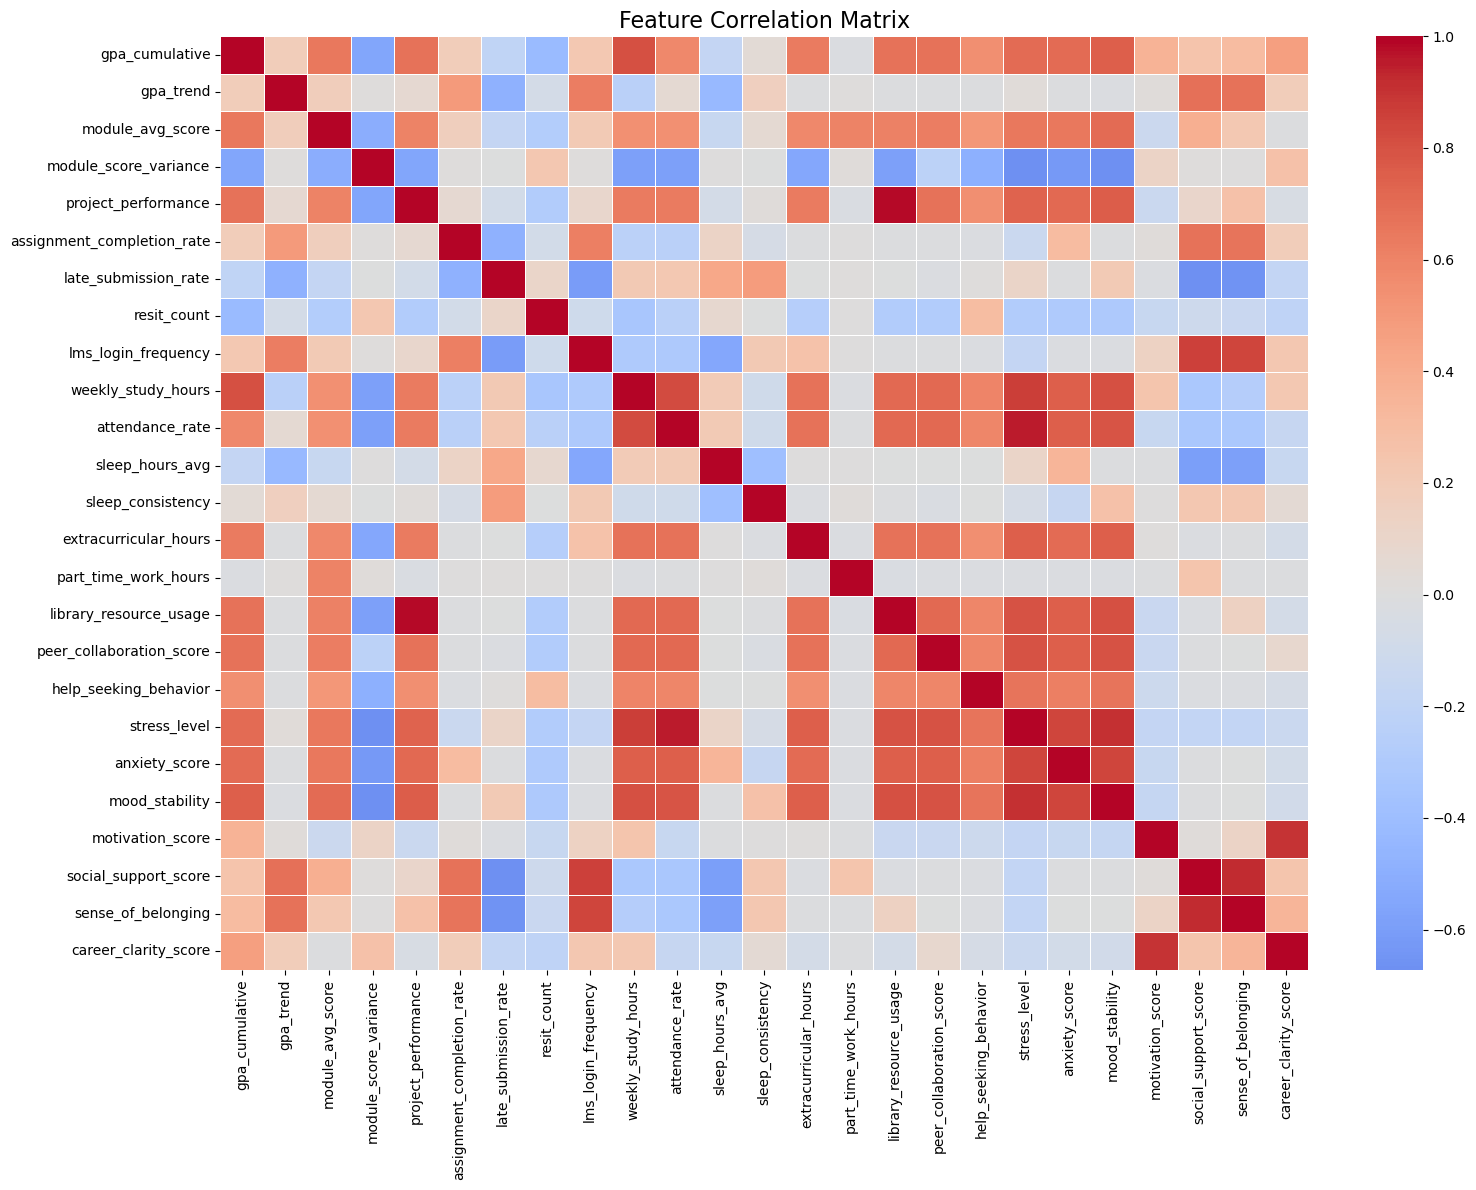

Saved: D:\R26-IT-153\backend\trained-models\career-prediction-engine\correlation_matrix.png
Highly correlated pairs (consider dropping one):


,Feature 1,Feature 2,Correlation
0,project_performance,library_resource_usage,0.986
1,lms_login_frequency,social_support_score,0.859
2,weekly_study_hours,stress_level,0.863
3,attendance_rate,stress_level,0.957
4,stress_level,mood_stability,0.905
5,motivation_score,career_clarity_score,0.896
6,social_support_score,sense_of_belonging,0.925


In [38]:
corr_matrix = X.corr()

CORR_IMG = r"D:\R26-IT-153\backend\trained-models\career-prediction-engine\correlation_matrix.png"

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.savefig(CORR_IMG, dpi=150)
plt.show()
print(f'Saved: {CORR_IMG}')

high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = abs(corr_matrix.iloc[i, j])
        if val > 0.85:
            high_corr.append({
                'Feature 1'  : corr_matrix.columns[i],
                'Feature 2'  : corr_matrix.columns[j],
                'Correlation': round(val, 3)
            })

if high_corr:
    print('Highly correlated pairs (consider dropping one):')
    display(pd.DataFrame(high_corr))
else:
    print('No dangerous multicollinearity (all pairs < 0.85).')

## Step 8 — Train/Test Split & Feature Scaling

In [39]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_risk, test_size=0.2, random_state=42, stratify=y_risk
)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_career, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_r_scaled = pd.DataFrame(scaler.fit_transform(X_train_r), columns=X.columns)
X_test_r_scaled  = pd.DataFrame(scaler.transform(X_test_r),      columns=X.columns)
X_train_c_scaled = pd.DataFrame(scaler.transform(X_train_c),     columns=X.columns)
X_test_c_scaled  = pd.DataFrame(scaler.transform(X_test_c),      columns=X.columns)

print(f'Risk   — Train: {X_train_r_scaled.shape} | Test: {X_test_r_scaled.shape}')
print(f'Career — Train: {X_train_c_scaled.shape} | Test: {X_test_c_scaled.shape}')

Risk   — Train: (8000, 25) | Test: (2000, 25)
Career — Train: (8000, 25) | Test: (2000, 25)


## Step 9 — Fix Class Imbalance (SMOTE)

In [40]:
print('Before SMOTE:')
display(pd.Series(y_train_r).value_counts().rename({0: 'Low', 1: 'Medium', 2: 'High'}).to_frame())

smote = SMOTE(random_state=42)
X_train_r_balanced, y_train_r_balanced = smote.fit_resample(X_train_r_scaled, y_train_r)

print('After SMOTE:')
display(pd.Series(y_train_r_balanced).value_counts().rename({0: 'Low', 1: 'Medium', 2: 'High'}).to_frame())
print('All 3 classes balanced.')

Before SMOTE:


,count
academic_risk_encoded,
Low,5783
Medium,1784
High,433


After SMOTE:


,count
academic_risk_encoded,
Low,5783
Medium,5783
High,5783


All 3 classes balanced.


## Step 10 — Save Model-Ready Objects

In [44]:
SAVED_DIR = Path(r"D:\R26-IT-153\backend\trained-models\career-prediction-engine\saved_objects")

SAVED_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(scaler,                                    SAVED_DIR / 'scaler.pkl')
joblib.dump(X.columns.tolist(),                        SAVED_DIR / 'feature_columns.pkl')
joblib.dump((X_train_r_balanced, y_train_r_balanced),  SAVED_DIR / 'risk_train.pkl')
joblib.dump((X_test_r_scaled,    y_test_r),            SAVED_DIR / 'risk_test.pkl')
joblib.dump((X_train_c_scaled,   y_train_c),           SAVED_DIR / 'career_train.pkl')
joblib.dump((X_test_c_scaled,    y_test_c),            SAVED_DIR / 'career_test.pkl')

#print(f"Saved to: {SAVED_DIR}")

for fname in sorted(SAVED_DIR.iterdir()):
    print(f"  {fname.name}")

Saved to: D:\R26-IT-153\backend\trained-models\career-prediction-engine\saved_objects
  career_test.pkl
  career_train.pkl
  feature_columns.pkl
  risk_test.pkl
  risk_train.pkl
  scaler.pkl


## Summary

In [42]:
print('=' * 60)
print('  PREPROCESSING COMPLETE')
print('=' * 60)
print(f'  Features used    : {X.shape[1]}')
print(f'  Target 1         : academic_risk_level (Low / Medium / High)')
print(f'  Target 2         : career_readiness_score (regression)')
print(f'  Train/Test split : 80% / 20%')
print(f'  Scaling          : StandardScaler (mean=0, std=1)')
print(f'  Imbalance fix    : SMOTE (train split only)')
#print(f'  Preprocessed CSV : {OUTPUT_CSV}')
#print(f'  Saved objects    : {SAVED_DIR}')
print('=' * 60)
print('  Ready for model_training.ipynb')
print('=' * 60)

  PREPROCESSING COMPLETE
  Features used    : 25
  Target 1         : academic_risk_level (Low / Medium / High)
  Target 2         : career_readiness_score (regression)
  Train/Test split : 80% / 20%
  Scaling          : StandardScaler (mean=0, std=1)
  Imbalance fix    : SMOTE (train split only)
  Ready for model_training.ipynb
